# Load timeseries files and test different approaches to finding the centre of deformation and temporal fitting

In [19]:
%matplotlib inline

from cmcrameri import cm
from skimage import filters
from skimage.feature import peak_local_max
from sklearn.cluster import DBSCAN
from scipy.signal import find_peaks, peak_prominences
from scipy.spatial import cKDTree
from scipy import ndimage as ndi
from skimage.segmentation import watershed
import matplotlib.pyplot as plt
import h5py
import numpy as np
import pandas as pd

# Load timeseries files and plot Cumulative disp

In [2]:
# Specify timeseries files
StorePath = '/work/xfc/vol7/user_cache/benirela/Other/Pedro_TS/'
EndPath = 'Wolf/106A/TS_GEOCml2clipmask/cum_filt.h5'
TS_File = StorePath + EndPath
#TS_File = StorePath + 'Dabbahu/014A/TS_GEOCml2clipmask/cum_filt.h5'

# Open timeseries file
with h5py.File(TS_File, "r") as f:
    ImDates = f["/imdates"][:]
    LOS = f["/cum"][:]
    cLat = f["/corner_lat"][()]
    cLon = f["/corner_lon"][()]
    postLat = f["/post_lat"][()]
    postLon = f["/post_lon"][()]

# Convert dates
DatesDT = pd.to_datetime(ImDates.astype(str), format="%Y%m%d")
days_ = (DatesDT - DatesDT[0]).days.to_numpy()

LOS = LOS.transpose((1, 2, 0))  # Transpose to (lat, lon, time)

# Find extent
endLat = (LOS.shape[0] - 1) * postLat + cLat
endLon = (LOS.shape[1] - 1) * postLon + cLon

# Create lat and lon postings and grids
lat = np.arange(cLat, endLat + postLat/2, postLat)
lon = np.arange(cLon, endLon + postLon/2, postLon)
Lon, Lat = np.meshgrid(lon, lat)

# Covert from mm to m
LOS = LOS / 1000.0

# Find maximum absolute displacement
CumDisp = LOS[:, :, -1]
MaxDisp = np.nanmax(abs(CumDisp))

### Locate Volcano of interest and mask other volcanoes in the frame

Target volcano location found: Wolf
No nearby volcanoes found


Text(0.5, 1.0, 'Target volcano masked')

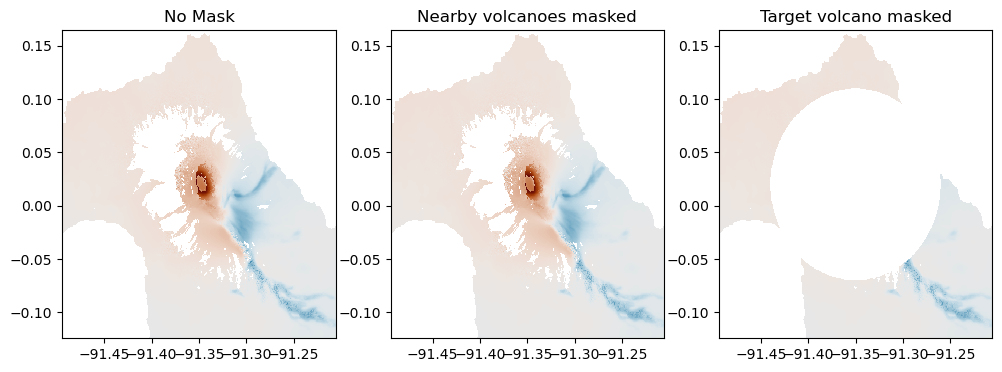

In [3]:
# Load GVP table:
GVP_Tab = '/work/xfc/vol7/user_cache/benirela/Other/GVP/GVP/GVP_Volcano_List_Holocene.xlsx'
GVP = pd.read_excel(GVP_Tab)

# Get volc name
VolcName = EndPath.split('/')[0]
VolcName = VolcName.replace('_', ' ')
#matches = GVP['Volcano Name'].str.contains(VolcName, case=False, na=False)
matches = GVP[GVP.iloc[:,1] == VolcName]
found = (GVP.iloc[:, 1].astype(str) == VolcName).any()

if found:
    print("Target volcano location found: " + VolcName)
else:
    print("No volcano name matching " + VolcName + " found in GVP table.")

# Get volc lat and lon
volcLat = matches.iloc[0, 8]
volcLon = matches.iloc[0, 9]

# Convert lat lon to km for buffering
bufferTargetVolc = 10 # in km
bufferOtherVolcs = 5 # in km
km_per_deg_lat = 111.32
km_per_deg_lon = 111.32 * np.cos(np.radians(volcLat))

volc_xy = np.column_stack([
    volcLon * km_per_deg_lon,
    volcLat * km_per_deg_lat
])

# Convert image pixels to km coordinates
LL_xy = np.column_stack([
    (Lon.ravel() * km_per_deg_lon),
    (Lat.ravel() * km_per_deg_lat)
])

# Use KDTree to find pixels within buffer distance of volcano
LL_tree = cKDTree(LL_xy)
neighbors = LL_tree.query_ball_point(volc_xy, r=bufferTargetVolc)
mask = np.zeros(LOS.shape, dtype=bool)
for idx in neighbors:
    Row, Col = np.unravel_index(idx, (LOS.shape[0], LOS.shape[1]))
    mask[Row, Col, :] = True

LOS_ThisVolc = np.copy(LOS)
LOS_ThisVolc[mask] = np.nan

# Find other volcanoes within the LOS extent + Buffer distance
MaxLon = (np.max(LL_xy[:, 0]) + bufferOtherVolcs)/km_per_deg_lon
MinLon = (np.min(LL_xy[:, 0]) - bufferOtherVolcs)/km_per_deg_lon
MaxLat = (np.max(LL_xy[:, 1]) + bufferOtherVolcs)/km_per_deg_lat
MinLat = (np.min(LL_xy[:, 1]) - bufferOtherVolcs)/km_per_deg_lat

GVP.iloc[:, 8] = pd.to_numeric(GVP.iloc[:, 8], errors="coerce")
GVP.iloc[:, 9] = pd.to_numeric(GVP.iloc[:, 9], errors="coerce")

latStr = GVP.iloc[:, 8]
lonStr = GVP.iloc[:, 9]
name = GVP.iloc[:,1]

# Filter to nearby volcanoes except target
Frame_Volcs = GVP[
    (GVP.iloc[:, 8] >= MinLat) &
    (GVP.iloc[:, 8] <= MaxLat) &
    (GVP.iloc[:, 9] >= MinLon) &
    (GVP.iloc[:, 9] <= MaxLon) &
    (GVP.iloc[:, 1] != VolcName)
]

if not Frame_Volcs.empty:
    print("Nearby volcanoes found:")
    print(Frame_Volcs.iloc[:, 1])
    # Create mask based on nearby volcanoes
    nearVolc_xy = np.column_stack([
        Frame_Volcs.iloc[:, 9] * km_per_deg_lon,
        Frame_Volcs.iloc[:, 8] * km_per_deg_lat
    ])
    neighbors2 = LL_tree.query_ball_point(nearVolc_xy, r=bufferOtherVolcs)
    mask2 = np.zeros(LOS.shape, dtype=bool)
    for idx in neighbors2:
        Row, Col = np.unravel_index(idx, (LOS.shape[0], LOS.shape[1]))
        mask2[Row, Col, :] = True

    LOS_NeabyVolcs = np.copy(LOS)
    LOS_NeabyVolcs[mask2] = np.nan
else:
    print("No nearby volcanoes found")
    LOS_NeabyVolcs = np.copy(LOS)

# Visualise masks
fig, axs = plt.subplots(1,3, figsize=(12, 4))
pcm = axs[0].pcolormesh(
    Lon,
    Lat,
    CumDisp,
    shading="auto",
    cmap=cm.vik,
    vmax=MaxDisp,
    vmin=-MaxDisp
)
axs[0].set_title("No Mask")

pcm = axs[1].pcolormesh(
    Lon,
    Lat,
    LOS_NeabyVolcs[:, :, -1],
    shading="auto",
    cmap=cm.vik,
    vmax=MaxDisp,
    vmin=-MaxDisp
)
axs[1].set_title("Nearby volcanoes masked")

pcm = axs[2].pcolormesh(
    Lon,
    Lat,
    LOS_ThisVolc[:, :, -1],
    shading="auto",
    cmap=cm.vik,
    vmax=MaxDisp,
    vmin=-MaxDisp
)
axs[2].set_title("Target volcano masked")

### Determine signal-noise ratio

In [4]:
# Define SNR function
def get_SNR(fullData, maskData, binWidth):
    maxD = np.nanmax(np.abs(fullData))
    # Plot histogram of temporal noise across each step outside the target volcano mask
    temporal_noise = np.nanstd(maskData, axis=2)
    temporal_noise = temporal_noise.flatten()
    temporal_noise = temporal_noise[~np.isnan(temporal_noise)]

    # Plot histogram of temporal noise
    binEdges = np.arange(-1,1,binWidth)
    counts, edges = np.histogram(temporal_noise, bins=binEdges)

    # Get bin with maximum count
    edge_max1 = edges[np.argmax(counts)]
    edge_max2 = edge_max1 + binWidth

    # Get mean of those in max bin
    Noise = np.mean(temporal_noise[(temporal_noise >= edge_max1) & (temporal_noise < edge_max2)])
    SNR = maxD/Noise
    return SNR, maxD, Noise, counts, edges, temporal_noise

Temporal noise: 0.75 cm
Max. Signal: 61.58 cm
Signal-to-noise ratio: 81.87


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


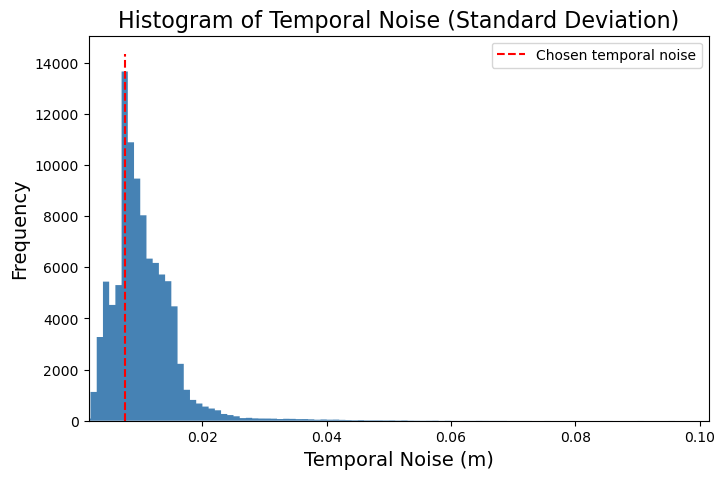

In [58]:
binW = 0.001 # Bin width in meters (1 mm)
SNR, max_disp_all, Noise, counts, edges, temporal_noise = get_SNR(LOS,LOS_ThisVolc,binW)

print('Temporal noise: ' + str(round(Noise*100, 2)) + ' cm')
print('Max. Signal: ' + str(round(max_disp_all*100, 2)) + ' cm')
print('Signal-to-noise ratio: ' + str(round(SNR, 2)))
FullSNR = SNR

fig, ax = plt.subplots(1,1, figsize=(8, 5))
ax.stairs(counts, edges, fill=True, color='steelblue', edgecolor='black')
ax.set_title('Histogram of Temporal Noise (Standard Deviation)', fontsize=16)
ax.set_xlabel('Temporal Noise (m)', fontsize=14)
ax.set_ylabel('Frequency', fontsize=14)
ax.set_xlim(min(temporal_noise), max(temporal_noise))
ax.vlines(Noise, plt.ylim()[0], plt.ylim()[1], color='red', linestyle='--', label='Chosen temporal noise')
ax.legend()

## Methods - Determine how many signals and deformation centres

In [39]:
SNRThresh = 3
SNRThresh_maybe = 2
T_winsize = 1 # Timeseries window size in years
if SNR > SNRThresh:
    print("SNR is greater than " + str(SNRThresh) + ", looking for signals")
    
    # Get timeseries indexes to query
    yrs = days_ / 365.25
    TS_Len = yrs[-1]
    yrsQ = np.arange(T_winsize,np.ceil(TS_Len),T_winsize)
    
    idxYrs = np.empty((len(yrsQ),1))
    idxYrs.fill(np.nan)
    for i , j in enumerate(yrsQ):
        idxYrs[i] = np.argmin(abs(yrs-j))
    idxYrs = idxYrs.astype(int).flatten()

    # Calculate SNR at every T_winsize in the dataset and index of biggest point
    Set_SNR = np.empty((len(yrsQ),1))
    Set_SNR.fill(np.nan)
    Set_maxD = Set_SNR.copy()
    Set_Noise = Set_SNR.copy()
    Set_SNR_Inc = Set_SNR.copy()
    Set_maxD_Inc = Set_SNR.copy()
    Set_Noise_Inc = Set_SNR.copy()
    RowIdx = Set_SNR.copy()
    ColIdx = Set_SNR.copy()
    TimeIdx = Set_SNR.copy()
    RowIdxInc = Set_SNR.copy()
    ColIdxInc = Set_SNR.copy()
    TimeIdxInc = Set_SNR.copy()
    StartIdx = Set_SNR.copy()
    StartYr = Set_SNR.copy()
    EndYr = Set_SNR.copy()

    for i in range(len(yrsQ)):
        if i==0:
            # Extract cumulative disp. during timeperiod X-Y
            Set_CumDisp = LOS[:,:,0:idxYrs[i]]
            Set_CumDispMask = LOS_ThisVolc[:,:,0:idxYrs[i]]

            Set_IncDisp = Set_CumDisp.copy()
            Set_IncDispMask = Set_CumDispMask.copy()

            StartIdx[i] = 0
        else:
            # Extract cumulative disp. during timeperiod X-Y
            Set_CumDisp = LOS[:,:,idxYrs[i-1]:idxYrs[i]]
            Set_CumDispMask = LOS_ThisVolc[:,:,idxYrs[i-1]:idxYrs[i]]

            # Extract stepwise disp. during timeperiod X-Y
            Set_IncDisp = LOS[:,:,idxYrs[i-1]:idxYrs[i]] - LOS[:,:,idxYrs[i-1]][:, :, None]
            Set_IncDispMask = LOS_ThisVolc[:,:,idxYrs[i-1]:idxYrs[i]] - LOS_ThisVolc[:,:,idxYrs[i-1]][:, :, None]

            StartIdx[i] = idxYrs[i-1]

        # Get spatial and temporal location of highest displacement during the timeperiod
        RowIdx[i], ColIdx[i], TimeIdx[i] = np.unravel_index(np.nanargmax(np.abs(Set_CumDisp)), Set_CumDisp.shape)
        RowIdxInc[i], ColIdxInc[i], TimeIdxInc[i] = np.unravel_index(np.nanargmax(np.abs(Set_CumDisp)), Set_IncDisp.shape)
        TimeIdx[i] = TimeIdx[i] + StartIdx[i]
        TimeIdxInc[i] = TimeIdxInc[i] + StartIdx[i]
        StartYr[i] = i-1
        EndYr[i] = i
        # Get SNR
        Set_SNR[i], Set_maxD[i], Set_Noise[i], _, _, _ = get_SNR(Set_CumDisp,Set_CumDispMask,binW)
        Set_SNR_Inc[i], Set_maxD_Inc[i], Set_Noise_Inc[i], _, _, _ = get_SNR(Set_IncDisp,Set_IncDispMask,binW)
        
        # if SNR(i)<SNRThresh:
        #     if i==1:
        #         Set_CumDisp = LOS[:,:,1:idx(i)]
        #         Set_CumDispMask = LOS_ThisVolc[:,:,1:idx(i)]
        #     else:
        #         Set_CumDisp = LOS[:,:,idx(i-1):idx(i)]
        #         Set_CumDispMask = LOS_ThisVolc[:,:,1:idx(i)]

    
elif SNR > SNRThresh_maybe:
    print("SNR is greater than " + str(SNRThresh_maybe) + ", but not greater than " + str(SNRThresh) + ", may be looking for signals")

else:
    print("SNR is less than or equal to " + str(SNRThresh_maybe) + ", likely no signals above noise level")


SNR is greater than 3, looking for signals


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


### Visualise biggest deformation points in different timeperiods

Text(0.5, 0.98, 'Cumulative displacements')

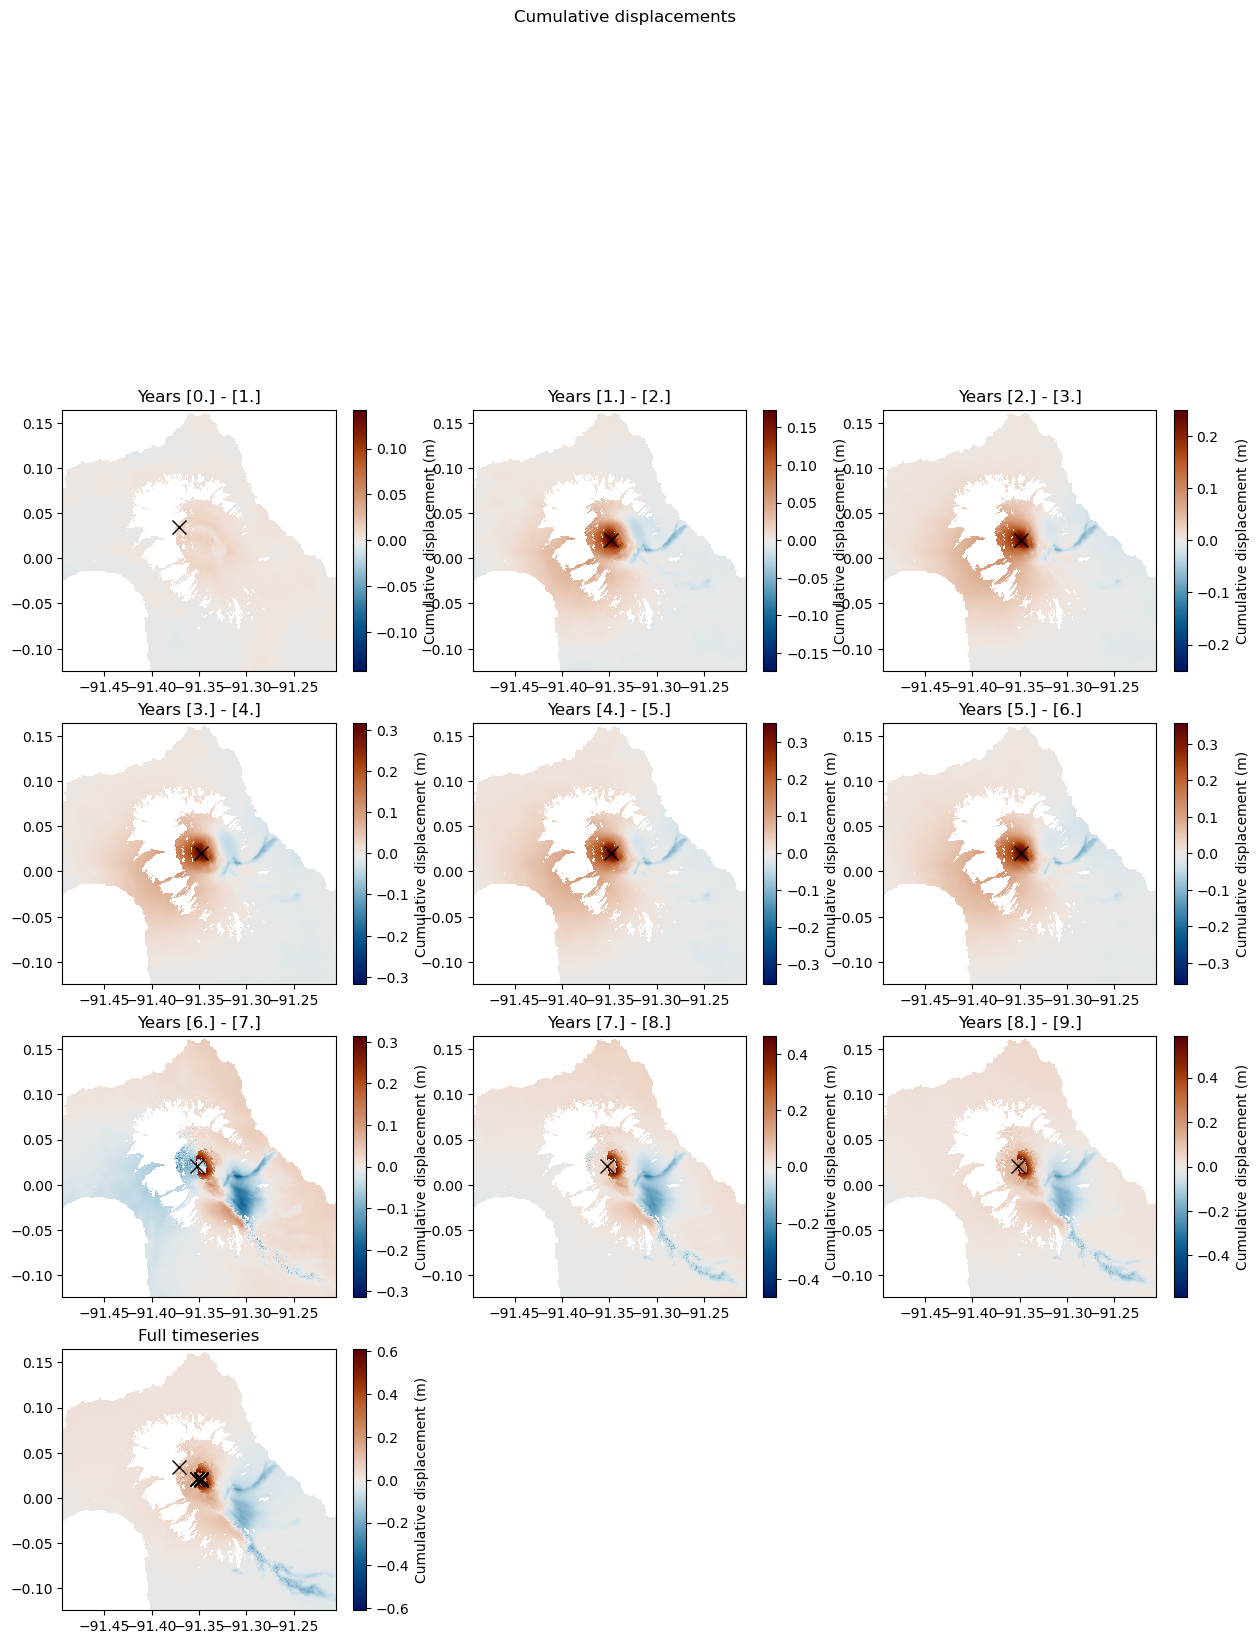

In [15]:
# Plot outputs of SNR tests
numCols = 3
numRows = np.ceil(len(yrsQ)+1/numCols).astype(int)
fig, axs = plt.subplots(numRows,numCols, figsize=(15,40))

TimeIdx = TimeIdx.astype(int).flatten()
RowIdx = RowIdx.astype(int).flatten()
ColIdx = ColIdx.astype(int).flatten()
StartIdx = StartIdx.astype(int).flatten()

nplots = len(yrsQ) + 1  # +1 for full timeseries
total_slots = numRows * numCols

for k in range(min(nplots, total_slots)):

    i, j = divmod(k, numCols)

    # Choose data
    if k == len(yrsQ):
        Disp = CumDisp.copy()
        title = "Full timeseries"
        x = Lon[RowIdx, ColIdx]
        y = Lat[RowIdx, ColIdx]
    else:
        Disp = LOS[:, :, TimeIdx[k]]
        title = f"Years {StartYr[k]+1} - {EndYr[k]+1}"
        x = Lon[RowIdx[k], ColIdx[k]]
        y = Lat[RowIdx[k], ColIdx[k]]

    # Plot field
    pcm = axs[i, j].pcolormesh(
        Lon,
        Lat,
        Disp,
        shading="auto",
        cmap=cm.vik,
        vmax=np.nanmax(abs(Disp)),
        vmin=-np.nanmax(abs(Disp))
    )

    axs[i, j].set_title(title)

    # Colorbar (per subplot, same as your original logic)
    cbar = plt.colorbar(pcm, ax=axs[i, j])
    cbar.set_label("Cumulative displacement (m)")

    # Marker
    axs[i, j].plot(x, y, "kx", markersize=10)

for k in range(nplots, total_slots):
    i, j = divmod(k, numCols)
    axs[i, j].set_visible(False)

plt.suptitle("Cumulative displacements")

### Step-wise displacements

Text(0.5, 0.98, 'Stepwise displacements')

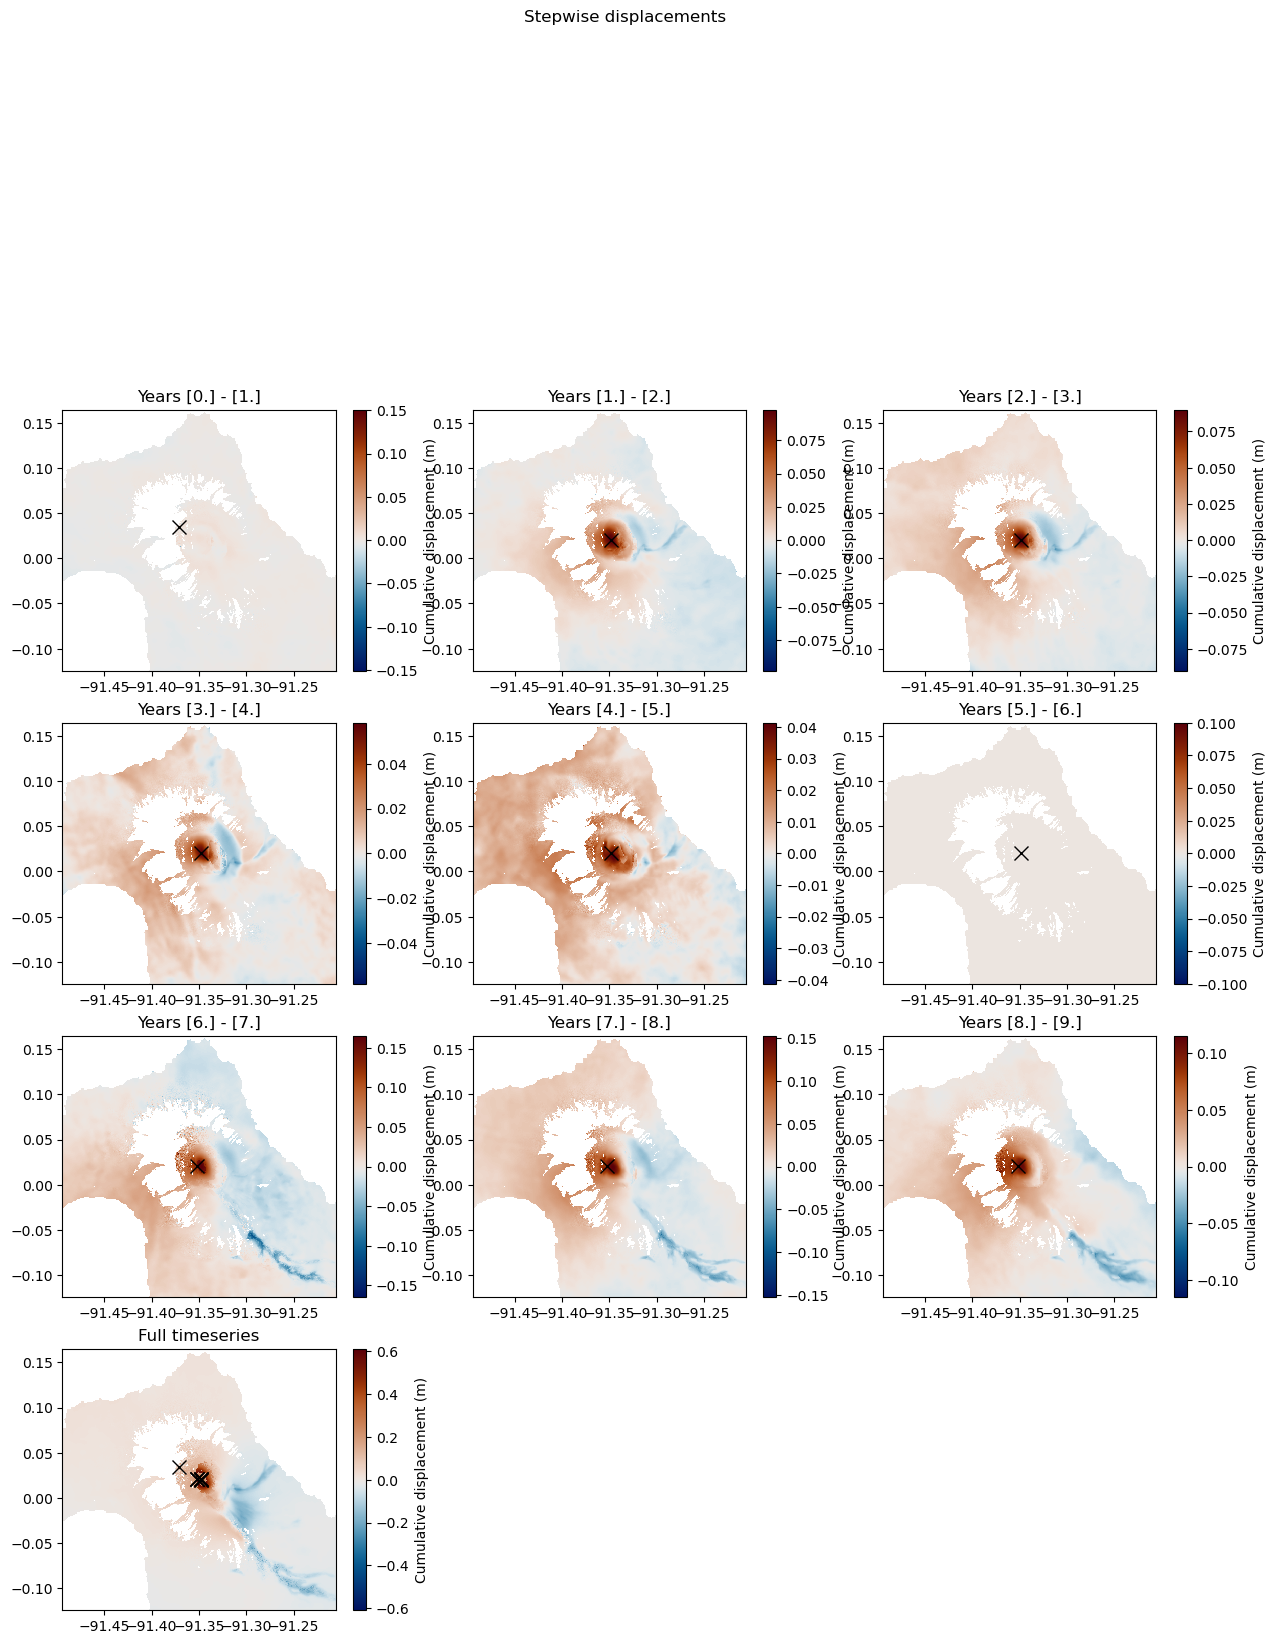

In [18]:
# Plot outputs of SNR tests
numCols = 3
numRows = np.ceil(len(yrsQ)+1/numCols).astype(int)
fig, axs = plt.subplots(numRows,numCols, figsize=(15, 40))

TimeIdxInc = TimeIdxInc.astype(int).flatten()
RowIdxInc = RowIdxInc.astype(int).flatten()
ColIdxInc = ColIdxInc.astype(int).flatten()
StartIdx = StartIdx.astype(int).flatten()

nplots = len(yrsQ) + 1  # +1 for full timeseries
total_slots = numRows * numCols

Disp_Steps = np.empty([LOS.shape[0],LOS.shape[1],len(yrsQ)])

for k in range(min(nplots, total_slots)):

    i, j = divmod(k, numCols)

    # Choose data
    if k == len(yrsQ):
        Disp = CumDisp.copy()
        title = "Full timeseries"
        x = Lon[RowIdxInc, ColIdxInc]
        y = Lat[RowIdxInc, ColIdxInc]
    else:
        Disp = LOS[:, :, TimeIdxInc[k]] - LOS[:,:, StartIdx[k]]
        title = f"Years {StartYr[k]+1} - {EndYr[k]+1}"
        x = Lon[RowIdxInc[k], ColIdxInc[k]]
        y = Lat[RowIdxInc[k], ColIdxInc[k]]

        Disp_Steps[:,:,k] = Disp

    # Plot field
    pcm = axs[i, j].pcolormesh(
        Lon,
        Lat,
        Disp,
        shading="auto",
        cmap=cm.vik,
        vmax=np.nanmax(abs(Disp)),
        vmin=-np.nanmax(abs(Disp))
    )

    axs[i, j].set_title(title)

    # Colorbar (per subplot, same as your original logic)
    cbar = plt.colorbar(pcm, ax=axs[i, j])
    cbar.set_label("Cumulative displacement (m)")

    # Marker
    axs[i, j].plot(x, y, "kx", markersize=10)

for k in range(nplots, total_slots):
    i, j = divmod(k, numCols)
    axs[i, j].set_visible(False)

plt.suptitle("Stepwise displacements")

### Methods - Cluster deformation centres

## Methods - deformation centre - smoothing

Text(0.5, 1.0, 'Smoothed cumulative displacement (Sigma = 1)')

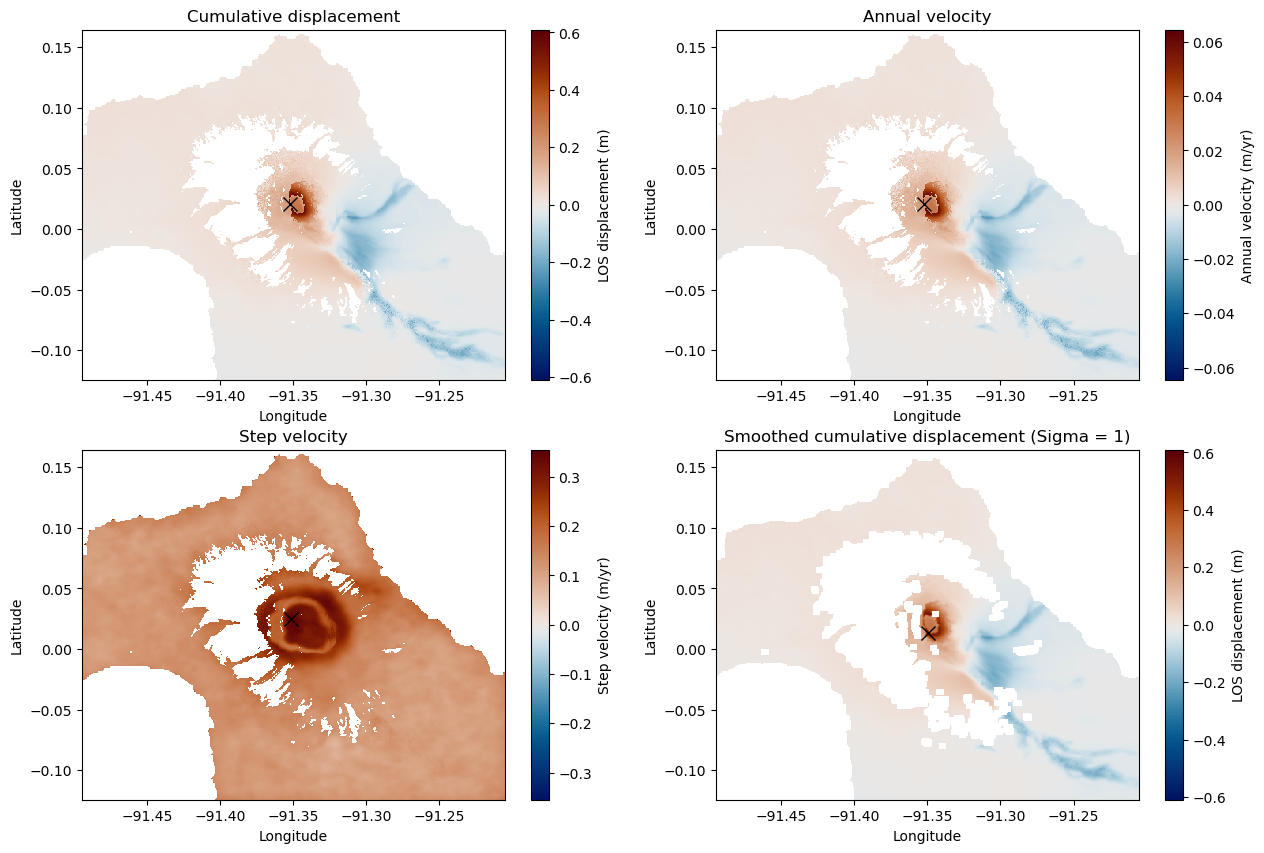

In [16]:
# Work out annual velocity
VelAnn = CumDisp / (days_[-1] / 365.25)

# Work out average absolute velocity between all timesteps at all pixels
VelStep = np.full(CumDisp.shape, np.nan, dtype=float)
for i in range(LOS.shape[0]):
    for j in range(LOS.shape[1]):
        if np.isnan(LOS[i,j,0]):
            VelStep[i, j] = np.nan
        else:
            VelStep[i, j] = np.nanmean(np.abs(np.diff(LOS[i, j, :]) / np.diff(days_ / 365.25)))

# Get locations
Idx_MaxD = np.nanargmax(abs(CumDisp))
Idx_MaxD_Lat, Idx_MaxD_Lon = np.unravel_index(Idx_MaxD, CumDisp.shape)
Idx_MaxVa = np.nanargmax(abs(VelAnn))
Idx_MaxVa_Lat, Idx_MaxVa_Lon = np.unravel_index(Idx_MaxVa, VelAnn.shape)
Idx_MaxVs = np.nanargmax(abs(VelStep))
Idx_MaxVs_Lat, Idx_MaxVs_Lon = np.unravel_index(Idx_MaxVs, VelStep.shape)

MaxVelA = np.nanmax(abs(VelAnn))
MaxVelS = np.nanmax(abs(VelStep))

# Try different filters for smoothing
sigma = 1
CumDisp_Smooth = filters.gaussian(CumDisp, sigma=sigma)
Idx_MaxDS = np.nanargmax(abs(CumDisp_Smooth))
Idx_MaxDS_Lat, Idx_MaxDS_Lon = np.unravel_index(Idx_MaxDS, CumDisp_Smooth.shape)

# Plot cumulative displacement and velocities
fig, axs = plt.subplots(2,2, figsize=(15, 10))

pcm = axs[0,0].pcolormesh(
    Lon,
    Lat,
    CumDisp,
    shading="auto",
    cmap=cm.vik,
    vmax=MaxDisp,
    vmin=-MaxDisp
)

cbar = plt.colorbar(pcm, ax=axs[0,0])
cbar.set_label("LOS displacement (m)")
axs[0,0].set_xlabel("Longitude")
axs[0,0].set_ylabel("Latitude")
axs[0,0].set_title("Cumulative displacement")

PLT = axs[0,0].plot(Lon[Idx_MaxD_Lat, Idx_MaxD_Lon], Lat[Idx_MaxD_Lat, Idx_MaxD_Lon], "kx", markersize=10, label="Max cumulative displacement")

pcm = axs[0,1].pcolormesh(
    Lon,
    Lat,
    VelAnn,
    shading="auto",
    cmap=cm.vik,
    vmax=MaxVelA,
    vmin=-MaxVelA   
)

cbar = plt.colorbar(pcm, ax=axs[0,1])
cbar.set_label("Annual velocity (m/yr)")
axs[0,1].set_xlabel("Longitude")
axs[0,1].set_ylabel("Latitude")
axs[0,1].set_title("Annual velocity")

PLT = axs[0,1].plot(Lon[Idx_MaxVa_Lat, Idx_MaxVa_Lon], Lat[Idx_MaxVa_Lat, Idx_MaxVa_Lon], "kx", markersize=10, label="Max annual velocity")

pcm = axs[1,0].pcolormesh(
    Lon,
    Lat,
    VelStep,
    shading="auto",
    cmap=cm.vik,
    vmax=MaxVelS,
    vmin=-MaxVelS
)

cbar = plt.colorbar(pcm, ax=axs[1,0])
cbar.set_label("Step velocity (m/yr)")
axs[1,0].set_xlabel("Longitude")
axs[1,0].set_ylabel("Latitude")
axs[1,0].set_title("Step velocity")

PLT = axs[1,0].plot(Lon[Idx_MaxVs_Lat, Idx_MaxVs_Lon], Lat[Idx_MaxVs_Lat, Idx_MaxVs_Lon], "kx", markersize=10, label="Max step velocity")

pcm = axs[1,1].pcolormesh(
    Lon,
    Lat,
    CumDisp_Smooth,
    shading="auto",
    cmap=cm.vik,
    vmax=MaxDisp,
    vmin=-MaxDisp
)

PLT = axs[1,1].plot(Lon[Idx_MaxDS_Lat, Idx_MaxDS_Lon], Lat[Idx_MaxDS_Lat, Idx_MaxDS_Lon], "kx", markersize=10, label="Max smoothed cumulative displacement")

cbar = plt.colorbar(pcm, ax=axs[1,1])
cbar.set_label("LOS displacement (m)")
axs[1,1].set_xlabel("Longitude")
axs[1,1].set_ylabel("Latitude")
axs[1,1].set_title(f"Smoothed cumulative displacement (Sigma = {sigma})")

### Methods - deformation centre - Watershed segmentation and Peak identification

Text(0.5, 1.0, 'SNR')

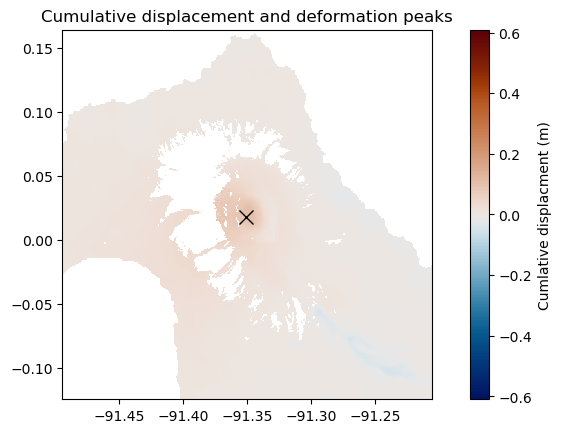

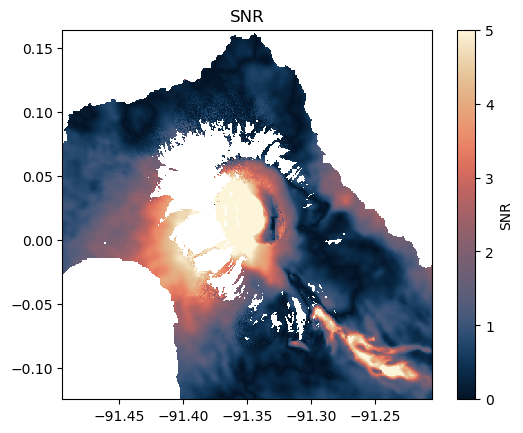

In [66]:
spaitalRes_m = 30
min_radius_km = 3
min_dist = round((min_radius_km*1000)/spaitalRes_m)
mask = np.isfinite(CumDisp_Smooth) # Mask NaN values
Im_SNR = np.abs(CumDisp)/Noise
Im_SNR_Smooth = np.abs(CumDisp_Smooth)/Noise

coordinates = peak_local_max(CumDisp_Smooth,min_distance=min_dist,threshold_abs=SNRThresh*Noise,labels=mask.astype(int))
coordinates = peak_local_max(CumDisp,min_distance=min_dist,threshold_abs=SNRThresh*Noise,labels=mask.astype(int))

fig = plt.figure(1)
pcm = plt.pcolormesh(
    Lon,
    Lat,
    CumDisp,
    shading="auto",
    cmap=cm.vik,
    vmax=MaxDisp,
    vmin=-MaxDisp
)
cbar = plt.colorbar(pcm)
cbar.set_label("Cumlative displacment (m)")
plt.plot(Lon[coordinates[:,1], coordinates[:,0]], Lat[coordinates[:,1], coordinates[:,0]], "kx", markersize=10, label="Local maxima")
plt.axis('image')
plt.title('Cumulative displacement and deformation peaks')

fig = plt.figure(2)
pcm = plt.pcolormesh(
    Lon,
    Lat,
    np.abs(CumDisp)/Noise,
    shading="auto",
    cmap=cm.lipari,
    vmax=5,
    vmin=0
)
plt.axis('image')
cbar = plt.colorbar(pcm)
cbar.set_label("SNR")
plt.title('SNR')

In [1]:
nRows = Disp_Steps.shape[2]

fig, axs = plt.subplots(
    nRows,
    2,
    figsize=(12, 4 * nRows),
    constrained_layout=True
)

# Handle the case nRows == 1
if nRows == 1:
    axs = axs[np.newaxis, :]

for k in range(nRows):

    CumDisp = Disp_Steps[:, :, k]
    MaxDisp = np.nanmax(np.abs(CumDisp))

    coordinates = peak_local_max(
        CumDisp,
        min_distance=min_dist,
        threshold_abs=SNRThresh * Noise,
        labels=mask.astype(int)
    )

    # -------------------------
    # Column 1: Displacement
    # -------------------------
    ax = axs[k, 0]

    pcm1 = ax.pcolormesh(
        Lon,
        Lat,
        CumDisp,
        shading="auto",
        cmap=cm.vik,
        vmax=MaxDisp,
        vmin=-MaxDisp
    )

    ax.plot(
        Lon[coordinates[:, 1], coordinates[:, 0]],
        Lat[coordinates[:, 1], coordinates[:, 0]],
        "kx",
        markersize=10
    )

    ax.set_aspect("equal")

    # Remove axis labels/tick labels
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    # Row title
    ax.set_title(f"Years {StartYr[k]+1} - {EndYr[k]+1}")

    cbar1 = fig.colorbar(pcm1, ax=ax)
    cbar1.set_label("")  # remove colourbar label

    # -------------------------
    # Column 2: SNR
    # -------------------------
    ax = axs[k, 1]

    snr = np.abs(CumDisp) / Noise

    pcm2 = ax.pcolormesh(
        Lon,
        Lat,
        snr,
        shading="auto",
        cmap=cm.lipari,
        vmax=5,
        vmin=0
    )

    ax.set_aspect("equal")

    # Remove axis labels/tick labels
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    cbar2 = fig.colorbar(pcm2, ax=ax)
    cbar2.set_label("")  # remove colourbar label

NameError: name 'Disp_Steps' is not defined

## Methods - Timeseries - Filtering

Text(0.5, 0.98, 'Filtering')

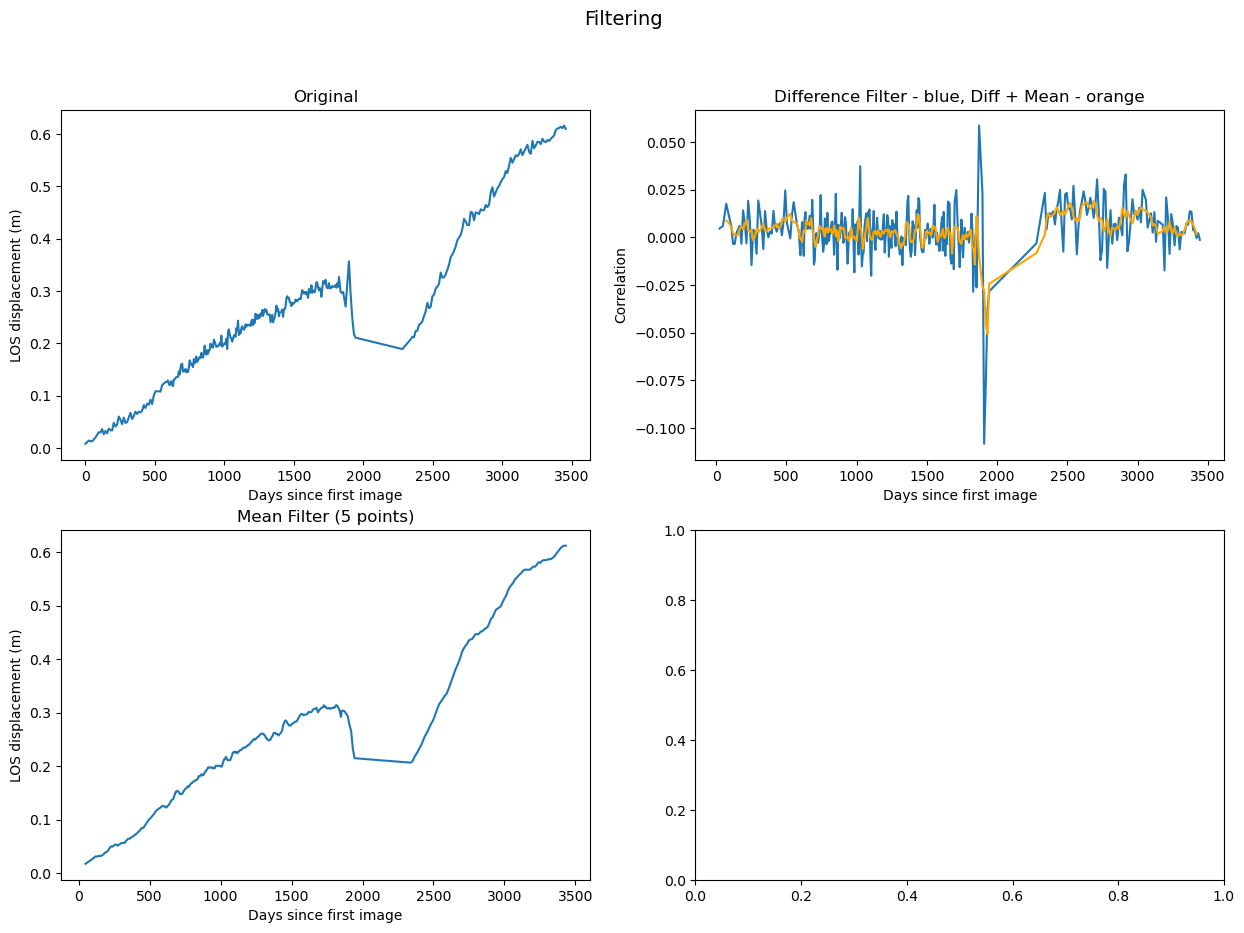

In [ ]:
# Plot timeseries
fig, axs = plt.subplots(2,2, figsize=(15, 10))
pixTS = LOS[Idx_MaxD_Lat, Idx_MaxD_Lon, :]
axs[0,0].plot(days_, pixTS, "-")
axs[0,0].set_xlabel("Days since first image")
axs[0,0].set_ylabel("LOS displacement (m)")
axs[0,0].set_title("Original")

# Mean filter
FiltSize = 5
mean_kernel = np.full((FiltSize,), 1/FiltSize)
smooth_signal3p = np.convolve(pixTS, mean_kernel,
                              mode='valid')
axs[1,0].plot(days_[2:-2], smooth_signal3p, "-")
axs[1,0].set_xlabel("Days since first image")
axs[1,0].set_ylabel("LOS displacement (m)")
axs[1,0].set_title("Mean Filter (5 points)")

# Difference filter
diff_filter_res= np.correlate(pixTS, np.array([-1, 0, 1]),
                           mode='valid')
double_diff_filter_res= np.convolve(diff_filter_res, mean_kernel,
                           mode='valid')
axs[0,1].plot(days_[1:-1], diff_filter_res, "-")
axs[0,1].plot(days_[3:-3], double_diff_filter_res, "-", color="orange")
axs[0,1].set_xlabel("Days since first image")
axs[0,1].set_ylabel("Correlation")
axs[0,1].set_title("Difference Filter - blue, Diff + Mean - orange")

# Combined mean and difference filter
fig.suptitle("Filtering", fontsize=14)

## Methods - Change point detection

In [ ]:
# Try CUSUM to detect change points in the timeseries
u = 0.01 # Target value (1 cm)
K = 0.5 * u # Reference value

def cusum(data, target, k):
    n = len(data)
    C = np.zeros(n)
    for i in range(1, n):
        C[i] = max(0, C[i-1] + data[i] - target - k)
    return C

C = cusum(pixTS, u, K)